In [1]:
from __future__ import annotations

import lhapdf

import numpy as np

from validphys.api import API
from validphys.fkparser import load_fktable
from validphys.loader import Loader
import matplotlib.pyplot as plt


# Generate data

## Theory ID 40001000

In [2]:
BCDMS_BEAM_ENERGIES = np.array([100, 120, 200, 280])

def snap_beam_energy(e_raw):
    """Map computed beam energies to nominal BCDMS values within 5%."""
    print("in snap beam energy")
    result = np.empty_like(e_raw)
    for i, e in enumerate(e_raw):
        rel_diff = np.abs(BCDMS_BEAM_ENERGIES - e) / BCDMS_BEAM_ENERGIES
        best = np.argmin(rel_diff)
        if rel_diff[best] > 0.05:
            import warnings
            warnings.warn(f"Computed E_beam={e:.1f} not within 5% of any nominal energy")
            result[i] = round(e)
        else:
            result[i] = BCDMS_BEAM_ENERGIES[best]
    return result

In [12]:
mp = 0.938
mp2 = mp**2

inp_p2 = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_P_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000, #208
}
inp_d2 = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_D_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000,
}

lcd_p2 = API.loaded_commondata_with_cuts(**inp_p2)
lcd_d2 = API.loaded_commondata_with_cuts(**inp_d2)

df_p2 = (
    lcd_p2.commondata_table.reset_index()
    .rename(
        columns={
            "kin1": "x",
            "kin2": "q2",
            "kin3": "y",
            "data": "F2_p",
            "stat": "error",
            "entry": "entry_p",
        },
    )
    .assign(
        idx_p=lambda df: df.index,
        E_beam=lambda df: snap_beam_energy(
            (df["q2"] / (2 * mp * df["x"] * df["y"])).to_numpy()
        ),
    )
)
df_d2 = (
    lcd_d2.commondata_table.reset_index()
    .rename(
        columns={
            "kin1": "x",
            "kin2": "q2",
            "kin3": "y",
            "data": "F2_d",
            "stat": "error",
            "entry": "entry_d",
        },
    )
    .assign(
        idx_d=lambda df: df.index,
        E_beam=lambda df: snap_beam_energy(
            (df["q2"] / (2 * mp * df["x"] * df["y"])).to_numpy()
        ),
    )
)

#modify merge function to remove double counting
merged_df2 = df_p2.merge(df_d2, on=["x", "q2", "E_beam"], suffixes=("_p", "_d")).assign(
    y_val=lambda df: (df["F2_p"] - df["F2_d"]),
    F2_d=lambda df: (df["F2_d"]),
    w2=lambda df: df["q2"] * (1 - df["x"]) / df["x"] + mp2,
)

# remove duplicates to match 248 entries as in paper, for full 611 entries just comment out this line
# merged_df2 = merged_df2.groupby(['x', 'q2', 'F2_d', 'entry_d']).first().reset_index()

# Extract q2_vals and y_real for later use
q2_vals2 = merged_df2["q2"].to_numpy()
y_real2 = merged_df2["y_val"].to_numpy()
# np.save("Dataset/q2_vals_newth.npy", q2_vals2)
# np.save("Dataset/y_real_newth.npy", y_real2)

in snap beam energy
in snap beam energy


In [6]:
entry_p_rel2 = merged_df2["entry_p"].to_numpy() - 1
entry_d_rel2 = merged_df2["entry_d"].to_numpy() - 1
print(entry_d_rel2)

q2_vals2 = merged_df2["q2"].to_numpy()

print(len(q2_vals2))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  63  64  65  66  67  68  69  70  71  72
  73  74  75  79  80  81  82  83  84  85  86  87  88  89  92  93  94  95
  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113
 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131
 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149
 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203
 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221
 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239
 240 241 242 243 244 245 246 247 248 249 250 251 25

In [6]:
import numpy as np
from validphys.api import API
from validphys.pineparser import pineappl_reader

theoryid = 40001000
t3_index = 2  # flavor index in FK table

# Load datasets (legacy names OK; they get mapped internally)
ds_p = API.dataset(dataset_input={"dataset": "BCDMS_NC_NOTFIXED_P_EM-F2"}, theoryid=theoryid, use_cuts="internal")
ds_d = API.dataset(dataset_input={"dataset": "BCDMS_NC_NOTFIXED_D_EM-F2"}, theoryid=theoryid, use_cuts="internal")

# Read PineAPPL FK tables for each dataset (often multiple sqrt(s) grids)
fk_p_list = [pineappl_reader(fkspec) for fkspec in ds_p.fkspecs]
fk_d_list = [pineappl_reader(fkspec) for fkspec in ds_d.fkspecs]

# If you truly need one combined FK table like the legacy case, you must pick the
# matching component for each datapoint. A simple starting point is to use the first.
fk_p2 = fk_p_list[0]
fk_d2 = fk_d_list[0]

print(fk_p2)

wp2 = fk_p2.get_np_fktable()  # (n_data_fk, n_flav, n_grid)
wd2 = fk_d2.get_np_fktable()

wp2_t3 = wp2[:, t3_index, :]
wd2_t3 = wd2[:, t3_index, :]

entry_p_rel2 = merged_df2["entry_p"].to_numpy() - 1
entry_d_rel2 = merged_df2["entry_d"].to_numpy() - 1

W2 = wp2_t3[entry_p_rel2] - wd2_t3[entry_d_rel2]  # (n_data, n_grid)
print(W2.shape)

# Save xgrid for later normalization
xgrid2 = fk_p2.xgrid.copy()  # (n_grid,)
print(fk_p2.xgrid.shape)
# Save for later use
# np.save("Dataset/W_newth.npy", W2)
# np.save("Dataset/xgrid_newth.npy", xgrid2)


FKTableData(hadronic=False, Q0=1.0, ndata=351, xgrid=array([0.00287387, 0.0043285 , 0.00649621, 0.00969916, 0.01437507,
       0.02108919, 0.03052158, 0.04341492, 0.06048003, 0.08228122,
       0.10914376, 0.14112081, 0.17802566, 0.21950413, 0.2651137 ,
       0.3143874 , 0.36687532, 0.42216678, 0.4798989 , 0.53975723,
       0.6014722 , 0.66481395, 0.72958684, 0.79562425, 0.86278393,
       0.93094408, 1.        ]), sigma=                   1             2             3             4             5   \
data x                                                                          
0    0   0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
     1   2.576106e-27  6.069118e-27  1.795509e-43  5.205035e-48 -7.173868e-44   
     2  -7.956479e-22 -1.387550e-21 -1.448743e-37 -3.155238e-39 -7.900809e-39   
     3   8.274516e-15  1.913565e-14  6.776172e-31  6.457974e-31 -3.157212e-31   
     4   6.553538e-10  1.117898e-09  1.526886e-25  1.096678e-25 -5.471530e-27   
...   

In [8]:
import numpy as np
from validphys.api import API

inp_p = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_P_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000, #208
}
inp_d = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_D_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000,
}

params_cov = {
    "dataset_inputs": [inp_p["dataset_input"], inp_d["dataset_input"]],
    "use_cuts": "internal",
    "theoryid": 40001000,
}
cov_full2 = API.dataset_inputs_covmat_from_systematics(**params_cov)


# Your merged indices are in the ORIGINAL (pre-cut) dataset index space
idx_p_merge2 = merged_df2["idx_p"].to_numpy()
idx_d_merge2 = merged_df2["idx_d"].to_numpy()

n_p2 = len(df_p2)
# Extract the proton-proton, deuteron-deuteron, and proton-deuteron sub-blocks:
c_pp2 = cov_full2[:n_p2, :n_p2]  # shape = (Np, Np)
c_dd2 = cov_full2[n_p2:, n_p2:]  # shape = (Nd, Nd)
c_pd2 = cov_full2[:n_p2, n_p2:]  # shape = (Np, Nd)

# Restrict to matched points only (now safe)
c_pp_sub2 = c_pp2[np.ix_(idx_p_merge2, idx_p_merge2)]
c_dd_sub2 = c_dd2[np.ix_(idx_d_merge2, idx_d_merge2)]
c_pd_sub2 = c_pd2[np.ix_(idx_p_merge2, idx_d_merge2)]

# Cov for y = p - d  =>  Cov(y) = Cov(p)+Cov(d)-Cov(p,d)-Cov(d,p)
c_yy2 = c_pp_sub2 + c_dd_sub2 - c_pd_sub2 - c_pd_sub2.T

# Force exact symmetry (numerical)
c_yy2 = 0.5 * (c_yy2 + c_yy2.T)

print("c_yy2 shape:", c_yy2.shape)

# Add jitter until positive-definite
jitter = 1e-6 * float(np.mean(np.diag(c_yy2)))
for _ in range(10):
    try:
        np.linalg.cholesky(c_yy2)
        break
    except np.linalg.LinAlgError:
        c_yy2 = c_yy2 + np.eye(c_yy2.shape[0]) * jitter
        jitter *= 10
else:
    raise RuntimeError("Covariance matrix not positive-definite even after jitter.")

# np.save("Dataset/c_yy_newth.npy", c_yy2)


c_yy2 shape: (248, 248)


In [10]:
#Compute reference for closure test, this should be the f0/y0
pdfset2 = lhapdf.getPDFSet("NNPDF40_nnlo_as_01180")  # This PDF can be changed to any toy underlying PDF set
pdf02 = pdfset2.mkPDF(0)
Q02 = fk_p2.Q0
xt3_true2 = np.zeros_like(xgrid2)


# T_3 = (u - ubar) - (d - dbar)
for i, x in enumerate(xgrid2):
    u2 = pdf02.xfxQ(2, x, Q02)
    ub2 = pdf02.xfxQ(-2, x, Q02)
    d2 = pdf02.xfxQ(1, x, Q02)
    db2 = pdf02.xfxQ(-1, x, Q02)
    xt3_true2[i] = (u2 - ub2) - (d2 - db2)


t32 = xt3_true2 / xgrid2 # Or here we can just input the true function directly for T3 or xT3

t3_ref_int2 = np.trapz(xt3_true2 / xgrid2, xgrid2)  # noqa: NPY201


y_theory2 = W2 @ (xt3_true2)  # shape (N,)
print(W2.shape)
print(xt3_true2.shape)
print(y_theory2)
print("----------------")
print(xt3_true2)
y_t3_theory2 = W2 @ (t32)  # shape (N,)

# np.save('Dataset/y_theory_newth.npy', y_theory2)
# np.save('Dataset/y_t3_theory_newth.npy', y_t3_theory2)
# np.save('Dataset/xt3_true_newth.npy', xt3_true2)
# np.save('Dataset/t3_true_newth.npy', t32)
print(len(y_theory2))

rng = np.random.default_rng(seed=451)  # you can set seed if you want reproducible “data”
noise2 = rng.multivariate_normal(mean=np.zeros(len(y_theory2)), cov=c_yy2)

y_pseudo2 = y_theory2 + noise2
#y_theory: y0, y_pseudo = y

LHAPDF 6.5.5 loading /opt/homebrew/Caskroom/miniconda/base/envs/nnpdf/share/LHAPDF/NNPDF40_nnlo_as_01180/NNPDF40_nnlo_as_01180_0000.dat
(248, 27)
(27,)
[-8.90078968e-20 -2.40574388e-18 -4.75084620e-18 -4.44973098e-18
 -3.22410331e-18 -4.81618214e-18 -3.34240154e-18 -2.23702862e-18
  1.62364572e-18  1.23688899e-18 -3.21785945e-18 -4.76263632e-18
 -2.89228131e-18 -4.93432618e-18  1.25775861e-18 -2.39610687e-18
  9.85915361e-19 -5.79651641e-18 -6.84127998e-18  5.10710966e-19
  2.15674285e-18  1.00232368e-18 -2.65268154e-18  1.18663831e-19
  4.18613233e-19 -2.23934703e-18 -4.43515407e-18 -3.49734189e-18
 -3.19908226e-18 -8.21645595e-18 -2.42309572e-19 -6.55926374e-19
 -5.60143955e-18 -3.26686016e-18 -2.02398914e-18  1.39286960e-18
 -2.17384390e-19  8.74236202e-19 -1.39331375e-18 -4.19789145e-18
 -6.35148637e-18 -3.99779976e-18 -8.92311778e-19 -5.54701904e-18
  3.05929169e-18 -1.92128351e-18 -3.72235899e-18 -2.81836066e-18
 -2.14064687e-18  1.61234171e-18 -3.46258746e-19 -1.36166436e-18
  3

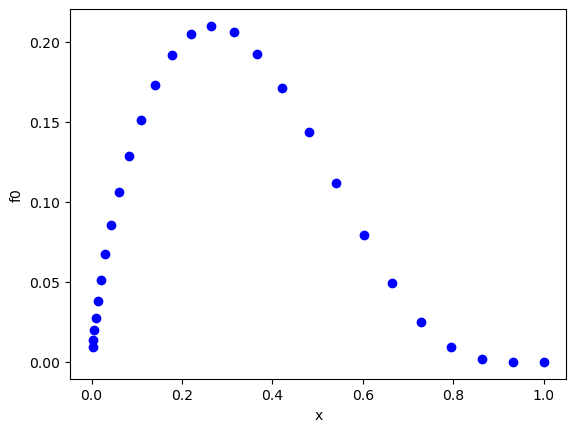

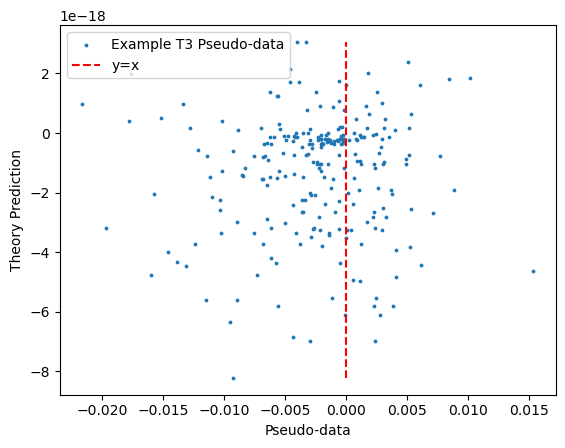

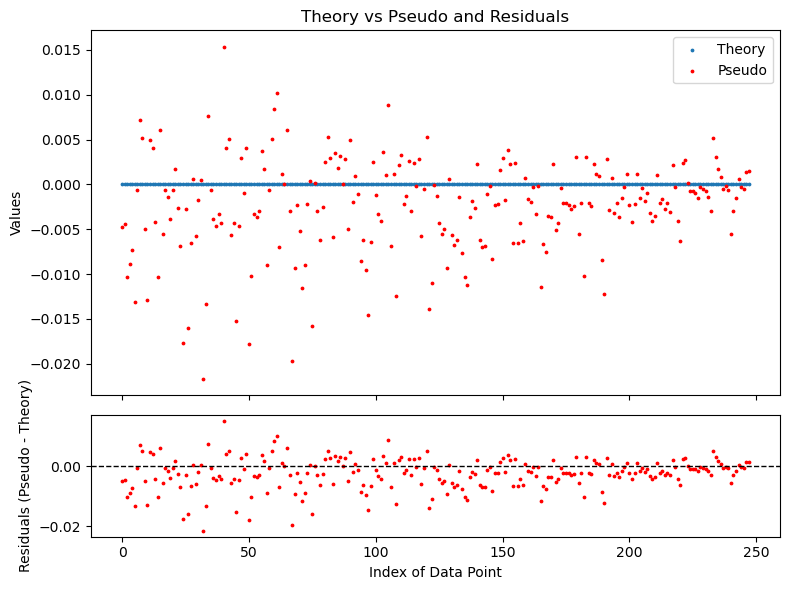

In [11]:
plt.scatter(xgrid2, xt3_true2, label="Example f0", color="blue")
plt.xlabel("x")
plt.ylabel("f0")
plt.show()
plt.close()

plt.scatter(y_pseudo2, y_theory2, label="Example T3 Pseudo-data",s=3)
plt.plot([min(y_theory2), max(y_theory2)],[min(y_theory2), max(y_theory2)], color="red", linestyle="--", label="y=x")

plt.legend()
plt.xlabel("Pseudo-data")
plt.ylabel("Theory Prediction")
plt.show()
plt.close()

residuals = y_pseudo2 - y_theory2

# Create two vertically stacked subplots (shared x-axis)
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 6), 
    gridspec_kw={'height_ratios': [3, 1]}, 
    sharex=True
)

# --- Top plot: theory vs pseudo
ax1.scatter(np.arange(len(y_theory2)), y_theory2, s=3, label='Theory')
ax1.scatter(np.arange(len(y_pseudo2)), y_pseudo2, s=3, label='Pseudo',color='r')
ax1.legend()
ax1.set_ylabel("Values")
ax1.set_title("Theory vs Pseudo and Residuals")

# --- Bottom plot: residuals
ax2.scatter(np.arange(len(residuals)), residuals, s=3, color='r')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel("Index of Data Point")
ax2.set_ylabel("Residuals (Pseudo - Theory)")

plt.tight_layout()
plt.show()
